# Intent & Topic Classifier (Model 3) — **Approach A: Honest / Imbalanced**
**Project:** SRH AI Platform — ALU Capstone (Rwandan Youth & PWDs)
**Input:** `data/Topic_Classifier_data/topic_{train,val,test}.csv`
**Output:** `models/topic_classifier_A.pkl` + comparison chart + confusion matrix

## Two-notebook experiment (read this)
The topic dataset is built by **weak supervision** (keyword matching over public
medical Q&A: MedMCQA, AdaptLLM, HealthCareMagic, AfriMedQA). After fixing the labeling
(word-boundary matching, no blanket subject maps) and removing the data leakage in the
original pipeline, two classes turn out to be **genuinely scarce** in the source data:
`gbv_consent` (~44 rows) and `disability_srh` (~50 rows). These are also the *most*
mission-critical classes for a platform serving youth and persons with disabilities.

There are two defensible ways to handle this, so we built one notebook for each:

| | **A (this notebook)** | **B** |
|---|---|---|
| Strategy | Train on the real data **as-is** | Add a hand-authored question bank for the two rare classes |
| Rare-class data | ~44 / ~50 real rows | Bolstered to ~220 each (templated, disclosed as synthetic) |
| Pro | **Honest** — metrics reflect true data reality; no synthetic data | Rare classes become **usable**; better recall on GBV/disability queries |
| Con | Rare classes will score poorly; macro-F1 dragged down | Val/test rare-class metrics partly measure templated text (**optimistic**) |
| Use it to argue | "This is what the data honestly supports." | "This is what a deployable model needs." |

**Approach A is the honest baseline.** Expect very low F1 on `gbv_consent` /
`disability_srh` — that is the finding, not a bug. Train-from-scratch (no pretrained
LLMs): TF-IDF + Logistic Regression / Linear SVM / XGBoost, same family as the safety
classifier (Model 1).

---
## STEP 0 — Install dependencies

In [1]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib
print('Dependencies ready.')

Dependencies ready.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## STEP 1 — Imports and config

In [2]:
APPROACH = 'Approach A — Honest / Imbalanced'
TAG = 'A'
import os, json, time, warnings, joblib, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

CANDIDATES = [
    'data/Topic_Classifier_data', '../data/Topic_Classifier_data',
    'srh-ml-model/data/Topic_Classifier_data', '.',
]
DATA_DIR = next((p for p in CANDIDATES
                 if os.path.exists(os.path.join(p, 'topic_train.csv'))), None)
assert DATA_DIR is not None, 'Could not find topic_train.csv — set DATA_DIR manually.'
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
print(f'Data directory : {DATA_DIR}')
print(f'Model directory: {MODEL_DIR}')

Data directory : ../data/Topic_Classifier_data
Model directory: models


---
## STEP 2 — Load the audited / cleaned data
Loads the three splits produced by `build_topic_dataset.py`. **No augmentation** —
this notebook trains on the real, imbalanced data exactly as labeled.

In [3]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'topic_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'topic_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'topic_test.csv'))
with open(os.path.join(DATA_DIR, 'topic_label_map.json')) as f:
    LABEL_MAP = json.load(f)
TOPIC_TO_INT = {k: int(v) for k, v in LABEL_MAP['topic_to_int'].items()}
INT_TO_TOPIC = {int(k): v for k, v in LABEL_MAP['int_to_topic'].items()}
CLASS_NAMES  = [INT_TO_TOPIC[i] for i in range(len(INT_TO_TOPIC))]
for df in (train_df, val_df, test_df):
    df['text'] = df['text'].fillna('').astype(str)
    df['label'] = df['label'].astype(int)
print('Base split sizes:  '
      f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')

Base split sizes:  train=7,616  val=1,632  test=1,632


---
## STEP 2b — Confirm splits, leakage check & class distribution

Leakage check  train&val=0  train&test=0  val&test=0

Class distribution per split:
                train  val  test
contraception    1589  341   340
sti_hiv          1589  341   340
pregnancy        1589  340   341
puberty          1198  256   257
gbv_consent        31    6     7
disability_srh     31    7     7
general_srh      1589  341   340


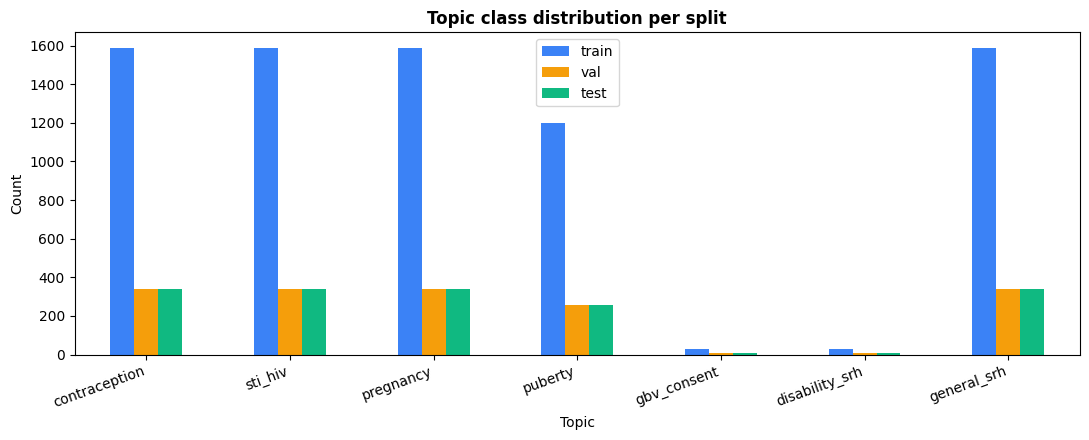

In [4]:
# ── Leakage guard (must stay zero even after augmentation) ──
def _keys(df): return set(df['text'].str.strip().str.lower())
ktr, kva, kte = _keys(train_df), _keys(val_df), _keys(test_df)
print(f'Leakage check  train&val={len(ktr & kva)}  train&test={len(ktr & kte)}'
      f'  val&test={len(kva & kte)}')
assert not (ktr & kva) and not (ktr & kte) and not (kva & kte), 'LEAKAGE DETECTED'

dist = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'val':   val_df['label'].value_counts().sort_index(),
    'test':  test_df['label'].value_counts().sort_index(),
}).fillna(0).astype(int)
dist.index = [INT_TO_TOPIC[i] for i in dist.index]
print('\nClass distribution per split:')
print(dist.to_string())

ax = dist.plot(kind='bar', figsize=(11, 4.5), color=['#3B82F6', '#F59E0B', '#10B981'])
ax.set_title('Topic class distribution per split', fontweight='bold')
ax.set_xlabel('Topic'); ax.set_ylabel('Count')
plt.xticks(rotation=20, ha='right'); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_class_distribution_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

X_train, y_train = train_df['text'], train_df['label'].values
X_val,   y_val   = val_df['text'],   val_df['label'].values
X_test,  y_test  = test_df['text'],  test_df['label'].values
N_CLASSES = len(CLASS_NAMES)

---
## STEP 3 — Feature extraction: TF-IDF (fit on train only)

In [5]:
TFIDF_PARAMS = dict(
    ngram_range   = (1, 2),
    max_features  = 30_000,
    sublinear_tf  = True,
    min_df        = 2,
    strip_accents = 'unicode',
    analyzer      = 'word',
    token_pattern = r'\b[a-zA-Z][a-zA-Z0-9]{1,}\b',
)

def make_pipeline(classifier):
    return Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', classifier)])

print('TF-IDF configured (ngram 1-2, max 30k features, fit on train only).')

TF-IDF configured (ngram 1-2, max 30k features, fit on train only).


---
## STEP 4 — Define the three models

In [6]:
import subprocess
def _xgb_device():
    # Use the Colab Pro GPU when present (device='cuda'); fall back to CPU locally.
    try:
        subprocess.run(['nvidia-smi'], capture_output=True, check=True)
        return 'cuda'
    except Exception:
        return 'cpu'
XGB_DEVICE = _xgb_device()
print(f'XGBoost device: {XGB_DEVICE}')

lr_pipeline = make_pipeline(
    LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs',
                       multi_class='multinomial', class_weight='balanced',
                       random_state=RANDOM_SEED))
svm_pipeline = make_pipeline(
    CalibratedClassifierCV(
        LinearSVC(C=0.5, max_iter=5000, class_weight='balanced',
                  random_state=RANDOM_SEED), cv=3))
xgb_pipeline = make_pipeline(
    XGBClassifier(objective='multi:softprob', num_class=7, n_estimators=300,
                  max_depth=6, learning_rate=0.1, subsample=0.8,
                  colsample_bytree=0.8, eval_metric='mlogloss', tree_method='hist',
                  device=XGB_DEVICE, random_state=RANDOM_SEED, n_jobs=-1))
MODELS = {'Logistic Regression': lr_pipeline, 'Linear SVM': svm_pipeline,
          'XGBoost': xgb_pipeline}
print('Models defined:'); [print(f'  - {n}') for n in MODELS]

XGBoost device: cpu
Models defined:
  - Logistic Regression
  - Linear SVM
  - XGBoost


[None, None, None]

---
## STEP 5 — Train & evaluate on the VALIDATION set
Test set untouched until Step 7.

In [7]:
y_val_bin = label_binarize(y_val, classes=list(range(N_CLASSES)))
results = {}
for name, pipeline in MODELS.items():
    print('\n' + '=' * 60); print(f'  Training: {name}'); print('=' * 60)
    fit_params = {}
    if name == 'XGBoost':
        fit_params['clf__sample_weight'] = compute_sample_weight('balanced', y_train)
    t0 = time.time(); pipeline.fit(X_train, y_train, **fit_params)
    train_time = time.time() - t0
    y_pred = pipeline.predict(X_val); y_prob = pipeline.predict_proba(X_val)
    acc         = accuracy_score(y_val, y_pred)
    f1_macro    = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    per_class   = f1_score(y_val, y_pred, average=None)
    roc_auc     = roc_auc_score(y_val_bin, y_prob, multi_class='ovr', average='macro')
    results[name] = {
        'accuracy': round(acc, 4), 'f1_macro': round(f1_macro, 4),
        'f1_weighted': round(f1_weighted, 4), 'roc_auc_ovr': round(roc_auc, 4),
        'train_sec': round(train_time, 1),
        'per_class_f1': {CLASS_NAMES[i]: round(float(per_class[i]), 4)
                         for i in range(N_CLASSES)}, 'pipeline': pipeline}
    print(f'  Train time   : {train_time:.1f}s')
    print(f'  Accuracy     : {acc:.4f}')
    print(f'  F1 Macro     : {f1_macro:.4f}   <- selection metric')
    print(f'  F1 Weighted  : {f1_weighted:.4f}')
    print(f'  ROC-AUC (ovr): {roc_auc:.4f}')
    print('  Per-class F1 :', {CLASS_NAMES[i]: round(float(per_class[i]),3) for i in range(N_CLASSES)})
    print('\n  Classification report (val):')
    print(classification_report(y_val, y_pred, target_names=CLASS_NAMES, zero_division=0))
print('\nAll models trained.')


  Training: Logistic Regression


  Train time   : 11.1s
  Accuracy     : 0.8781
  F1 Macro     : 0.8174   <- selection metric
  F1 Weighted  : 0.8787
  ROC-AUC (ovr): 0.9862
  Per-class F1 : {'contraception': 0.896, 'sti_hiv': 0.908, 'pregnancy': 0.876, 'puberty': 0.85, 'gbv_consent': 0.6, 'disability_srh': 0.727, 'general_srh': 0.864}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.94      0.86      0.90       341
       sti_hiv       0.95      0.87      0.91       341
     pregnancy       0.91      0.84      0.88       340
       puberty       0.80      0.91      0.85       256
   gbv_consent       0.75      0.50      0.60         6
disability_srh       1.00      0.57      0.73         7
   general_srh       0.81      0.93      0.86       341

      accuracy                           0.88      1632
     macro avg       0.88      0.78      0.82      1632
  weighted avg       0.89      0.88      0.88      1632


  Training: Linear SVM


  Train time   : 5.3s
  Accuracy     : 0.9191
  F1 Macro     : 0.8704   <- selection metric
  F1 Weighted  : 0.9192
  ROC-AUC (ovr): 0.9903
  Per-class F1 : {'contraception': 0.933, 'sti_hiv': 0.944, 'pregnancy': 0.91, 'puberty': 0.895, 'gbv_consent': 0.769, 'disability_srh': 0.727, 'general_srh': 0.915}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.95      0.92      0.93       341
       sti_hiv       0.95      0.94      0.94       341
     pregnancy       0.93      0.89      0.91       340
       puberty       0.86      0.93      0.90       256
   gbv_consent       0.71      0.83      0.77         6
disability_srh       1.00      0.57      0.73         7
   general_srh       0.90      0.93      0.91       341

      accuracy                           0.92      1632
     macro avg       0.90      0.86      0.87      1632
  weighted avg       0.92      0.92      0.92      1632


  Training: XGBoost


  Train time   : 414.1s
  Accuracy     : 0.9675
  F1 Macro     : 0.9531   <- selection metric
  F1 Weighted  : 0.9675
  ROC-AUC (ovr): 0.9931
  Per-class F1 : {'contraception': 0.979, 'sti_hiv': 0.977, 'pregnancy': 0.962, 'puberty': 0.964, 'gbv_consent': 1.0, 'disability_srh': 0.833, 'general_srh': 0.957}

  Classification report (val):
                precision    recall  f1-score   support

 contraception       0.99      0.97      0.98       341
       sti_hiv       0.98      0.98      0.98       341
     pregnancy       0.96      0.96      0.96       340
       puberty       0.95      0.98      0.96       256
   gbv_consent       1.00      1.00      1.00         6
disability_srh       1.00      0.71      0.83         7
   general_srh       0.96      0.96      0.96       341

      accuracy                           0.97      1632
     macro avg       0.98      0.94      0.95      1632
  weighted avg       0.97      0.97      0.97      1632


All models trained.


---
## STEP 6 — Model comparison & selection (by F1 macro)

Model comparison (sorted by F1 Macro):
              Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Train (s)
            XGBoost    0.9675    0.9531       0.9675   0.9931      414.1
         Linear SVM    0.9191    0.8704       0.9192   0.9903        5.3
Logistic Regression    0.8781    0.8174       0.8787   0.9862       11.1

Best model by F1 Macro: XGBoost  (F1 Macro = 0.9531)


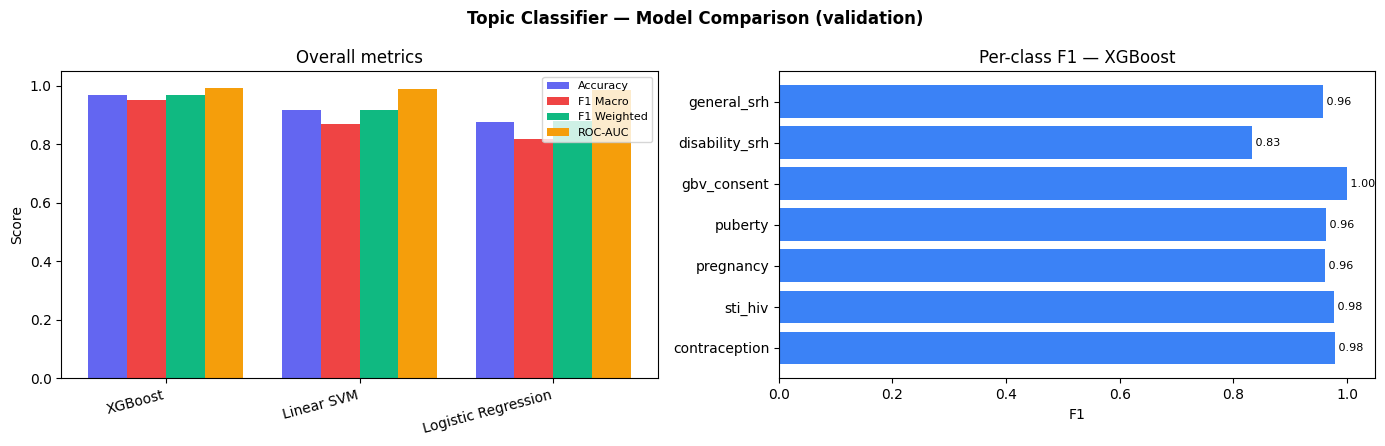

Saved: models/fig_topic_model_comparison_A.png


In [8]:
rows = [{'Model': n, 'Accuracy': r['accuracy'], 'F1 Macro': r['f1_macro'],
         'F1 Weighted': r['f1_weighted'], 'ROC-AUC': r['roc_auc_ovr'],
         'Train (s)': r['train_sec']} for n, r in results.items()]
comparison = pd.DataFrame(rows).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
print('Model comparison (sorted by F1 Macro):'); print(comparison.to_string(index=False))
best_name = comparison.iloc[0]['Model']; best_pipeline = results[best_name]['pipeline']
print(f'\nBest model by F1 Macro: {best_name}  (F1 Macro = {results[best_name]["f1_macro"]})')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Topic Classifier — Model Comparison (validation)', fontsize=12, fontweight='bold')
models = comparison['Model'].tolist(); x = np.arange(len(models)); w = 0.2
axes[0].bar(x-1.5*w, comparison['Accuracy'],    width=w, label='Accuracy',    color='#6366F1')
axes[0].bar(x-0.5*w, comparison['F1 Macro'],    width=w, label='F1 Macro',    color='#EF4444')
axes[0].bar(x+0.5*w, comparison['F1 Weighted'], width=w, label='F1 Weighted', color='#10B981')
axes[0].bar(x+1.5*w, comparison['ROC-AUC'],     width=w, label='ROC-AUC',     color='#F59E0B')
axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Score'); axes[0].set_title('Overall metrics')
axes[0].legend(fontsize=8)
pcf = results[best_name]['per_class_f1']
axes[1].barh(list(pcf.keys()), list(pcf.values()), color='#3B82F6')
axes[1].set_xlim(0, 1.05); axes[1].set_title(f'Per-class F1 — {best_name}'); axes[1].set_xlabel('F1')
for i, v in enumerate(pcf.values()): axes[1].text(v, i, f' {v:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_model_comparison_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'Saved: {MODEL_DIR}/fig_topic_model_comparison_{TAG}.png')

---
## STEP 7 — Evaluate the best model on the held-out TEST set
⚠️ **Run once.**

TEST SET RESULTS — XGBoost
  Accuracy     : 0.9706
  F1 Macro     : 0.9008
  F1 Weighted  : 0.9698
  ROC-AUC (ovr): 0.9968

                precision    recall  f1-score   support

 contraception       0.96      0.99      0.98       340
       sti_hiv       0.98      0.96      0.97       340
     pregnancy       0.97      0.96      0.97       341
       puberty       0.98      0.98      0.98       257
   gbv_consent       1.00      1.00      1.00         7
disability_srh       1.00      0.29      0.44         7
   general_srh       0.97      0.97      0.97       340

      accuracy                           0.97      1632
     macro avg       0.98      0.88      0.90      1632
  weighted avg       0.97      0.97      0.97      1632



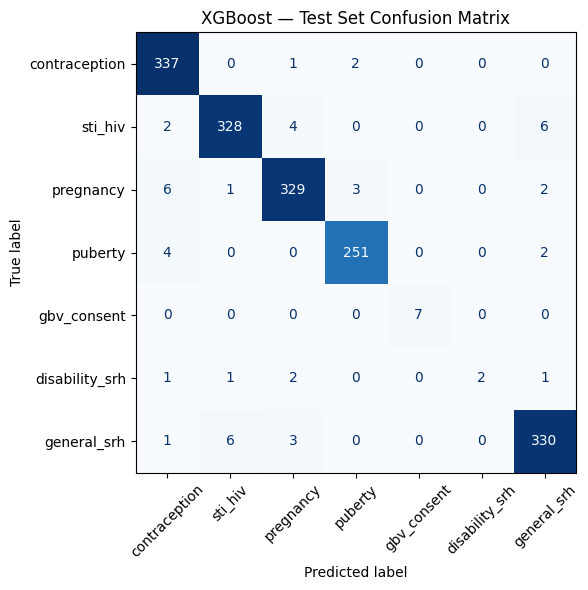

Saved: models/fig_topic_confusion_matrix_A.png


In [9]:
y_pred_test = best_pipeline.predict(X_test); y_prob_test = best_pipeline.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=list(range(N_CLASSES)))
test_acc      = accuracy_score(y_test, y_pred_test)
test_f1_macro = f1_score(y_test, y_pred_test, average='macro')
test_f1_wtd   = f1_score(y_test, y_pred_test, average='weighted')
test_auc      = roc_auc_score(y_test_bin, y_prob_test, multi_class='ovr', average='macro')
print(f'TEST SET RESULTS — {best_name}')
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  F1 Macro     : {test_f1_macro:.4f}')
print(f'  F1 Weighted  : {test_f1_wtd:.4f}')
print(f'  ROC-AUC (ovr): {test_auc:.4f}\n')
print(classification_report(y_test, y_pred_test, target_names=CLASS_NAMES, zero_division=0))
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=CLASS_NAMES,
    xticks_rotation=45, colorbar=False, cmap='Blues', ax=ax)
ax.set_title(f'{best_name} — Test Set Confusion Matrix'); plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/fig_topic_confusion_matrix_{TAG}.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'Saved: {MODEL_DIR}/fig_topic_confusion_matrix_{TAG}.png')

---
## STEP 8 — Save the winning pipeline + metadata

In [10]:
joblib.dump(best_pipeline, f'{MODEL_DIR}/topic_classifier_{TAG}.pkl')
meta = {'model': 'Model 3 — SRH Intent & Topic Classifier', 'approach': APPROACH,
        'best_model': best_name, 'classes': CLASS_NAMES,
        'features': 'TF-IDF (word, ngram 1-2, max 30k, sublinear)',
        'val_metrics': {k: results[best_name][k] for k in
                        ['accuracy', 'f1_macro', 'f1_weighted', 'roc_auc_ovr']},
        'val_per_class_f1': results[best_name]['per_class_f1'],
        'test_metrics': {'accuracy': round(test_acc, 4), 'f1_macro': round(test_f1_macro, 4),
                         'f1_weighted': round(test_f1_wtd, 4), 'roc_auc_ovr': round(test_auc, 4)},
        'rows': {'train': len(train_df), 'val': len(val_df), 'test': len(test_df)}}
with open(f'{MODEL_DIR}/topic_classifier_{TAG}_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Saved: {MODEL_DIR}/topic_classifier_{TAG}.pkl')
print(f'Saved: {MODEL_DIR}/topic_classifier_{TAG}_metadata.json')
print(json.dumps(meta, indent=2))

Saved: models/topic_classifier_A.pkl
Saved: models/topic_classifier_A_metadata.json
{
  "model": "Model 3 \u2014 SRH Intent & Topic Classifier",
  "approach": "Approach A \u2014 Honest / Imbalanced",
  "best_model": "XGBoost",
  "classes": [
    "contraception",
    "sti_hiv",
    "pregnancy",
    "puberty",
    "gbv_consent",
    "disability_srh",
    "general_srh"
  ],
  "features": "TF-IDF (word, ngram 1-2, max 30k, sublinear)",
  "val_metrics": {
    "accuracy": 0.9675,
    "f1_macro": 0.9531,
    "f1_weighted": 0.9675,
    "roc_auc_ovr": 0.9931
  },
  "val_per_class_f1": {
    "contraception": 0.9794,
    "sti_hiv": 0.9765,
    "pregnancy": 0.9617,
    "puberty": 0.9635,
    "gbv_consent": 1.0,
    "disability_srh": 0.8333,
    "general_srh": 0.9574
  },
  "test_metrics": {
    "accuracy": 0.9706,
    "f1_macro": 0.9008,
    "f1_weighted": 0.9698,
    "roc_auc_ovr": 0.9968
  },
  "rows": {
    "train": 7616,
    "val": 1632,
    "test": 1632
  }
}


---
## STEP 9 — Quick inference sanity check

In [11]:
loaded = joblib.load(f'{MODEL_DIR}/topic_classifier_{TAG}.pkl')
samples = [
    'Where can I get free condoms and birth control pills in Kigali?',
    'I think I was exposed to HIV, where can I get tested and start PrEP?',
    'I missed my period and the pregnancy test is positive, what now?',
    'My 13 year old daughter just started menstruating, is this normal puberty?',
    'Someone forced me to have sex without my consent, where can I report it?',
    'Can a person who uses a wheelchair safely use contraception?',
    'What is the difference between sex and gender in reproductive health?',
]
preds = loaded.predict(pd.Series(samples))
print(f'{"Predicted topic":<16}  Query'); print('-' * 90)
for q, p in zip(samples, preds): print(f'{INT_TO_TOPIC[int(p)]:<16}  {q[:70]}')

Predicted topic   Query
------------------------------------------------------------------------------------------
contraception     Where can I get free condoms and birth control pills in Kigali?
sti_hiv           I think I was exposed to HIV, where can I get tested and start PrEP?
puberty           I missed my period and the pregnancy test is positive, what now?
puberty           My 13 year old daughter just started menstruating, is this normal pube
general_srh       Someone forced me to have sex without my consent, where can I report i
contraception     Can a person who uses a wheelchair safely use contraception?
general_srh       What is the difference between sex and gender in reproductive health?


---
## STEP 10 — Summary & caveats

**How to read these results (Approach A):**
- This is the **honest baseline**. The two scarce classes (`gbv_consent`,
  `disability_srh`) have only a handful of real examples, so their per-class F1 is
  low and noisy — with ~6–8 test samples each, a single error swings the score a lot.
- `class_weight='balanced'` (and balanced `sample_weight` for XGBoost) is the only
  imbalance lever used; **no synthetic data**.
- Labels are weak-supervision (keyword-derived), not human-annotated, so even the
  strong classes carry some label noise.
- **Compare against Notebook B**, which bolsters the two rare classes with an authored
  question bank — higher rare-class recall, but optimistic rare-class evaluation.

In [12]:
print('=' * 68)
print(f'TOPIC CLASSIFIER (Model 3) — {APPROACH} — COMPLETE')
print('=' * 68)
print(f'  Winning model : {best_name}  (selected by F1 macro)')
print(f'  Rows          : train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')
print('\n  Validation comparison:'); print(comparison.to_string(index=False))
print('\n  Held-out TEST metrics:')
print(f'    Accuracy     : {test_acc:.4f}')
print(f'    F1 Macro     : {test_f1_macro:.4f}')
print(f'    F1 Weighted  : {test_f1_wtd:.4f}')
print(f'    ROC-AUC (ovr): {test_auc:.4f}')
pcf_test = f1_score(y_test, y_pred_test, average=None)
order = sorted(range(N_CLASSES), key=lambda i: pcf_test[i])
print('\n  Weakest classes  :', ', '.join(f'{CLASS_NAMES[i]} ({pcf_test[i]:.2f})' for i in order[:2]))
print('  Strongest classes:', ', '.join(f'{CLASS_NAMES[i]} ({pcf_test[i]:.2f})' for i in order[-2:]))
print()
print('  Approach A caveats:')
print('   - Honest baseline: no synthetic data; gbv_consent / disability_srh are')
print('     scarce (~44 / ~50 real rows) so their F1 is low and high-variance.')
print('   - Weak-supervision (keyword) labels carry noise even on strong classes.')
print('   - See Notebook B for the authored-bank alternative.')
print('=' * 68)

TOPIC CLASSIFIER (Model 3) — Approach A — Honest / Imbalanced — COMPLETE
  Winning model : XGBoost  (selected by F1 macro)
  Rows          : train=7,616  val=1,632  test=1,632

  Validation comparison:
              Model  Accuracy  F1 Macro  F1 Weighted  ROC-AUC  Train (s)
            XGBoost    0.9675    0.9531       0.9675   0.9931      414.1
         Linear SVM    0.9191    0.8704       0.9192   0.9903        5.3
Logistic Regression    0.8781    0.8174       0.8787   0.9862       11.1

  Held-out TEST metrics:
    Accuracy     : 0.9706
    F1 Macro     : 0.9008
    F1 Weighted  : 0.9698
    ROC-AUC (ovr): 0.9968

  Weakest classes  : disability_srh (0.44), pregnancy (0.97)
  Strongest classes: puberty (0.98), gbv_consent (1.00)

  Approach A caveats:
   - Honest baseline: no synthetic data; gbv_consent / disability_srh are
     scarce (~44 / ~50 real rows) so their F1 is low and high-variance.
   - Weak-supervision (keyword) labels carry noise even on strong classes.
   - See Noteb